# One House Example

## Setup

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import scipy.stats
from pathlib import Path

cwd = Path.cwd()  # Set cwd to Code folder
plot_folder = cwd.parent/'Plots/One_House_Example'

## Forward Model

Using $I_{i,j} = \dfrac{V_{j} - V_{i}}{\sigma_{i,j}L_{i,j}}$ and $P_{i} = V_{i}I_{i,j}$ we get:

$V_{i} = \dfrac{V_{j} + \sqrt{V^{2}_{j} - \sigma_{i,j}L_{i,j}P_{i}}}{2}$, discarding negative root as unstable

Where $\sigma_{i,j}$ is the wire resistance between two nodes, $L_{i,j}$ is the length between two nodes, $I_{i,j}$ is the current between two nodes

$P_{i}$ is unknown but can be modeled from an underlying distribution

6.1892015719080735 0.7487990384609211 487.4567516352027


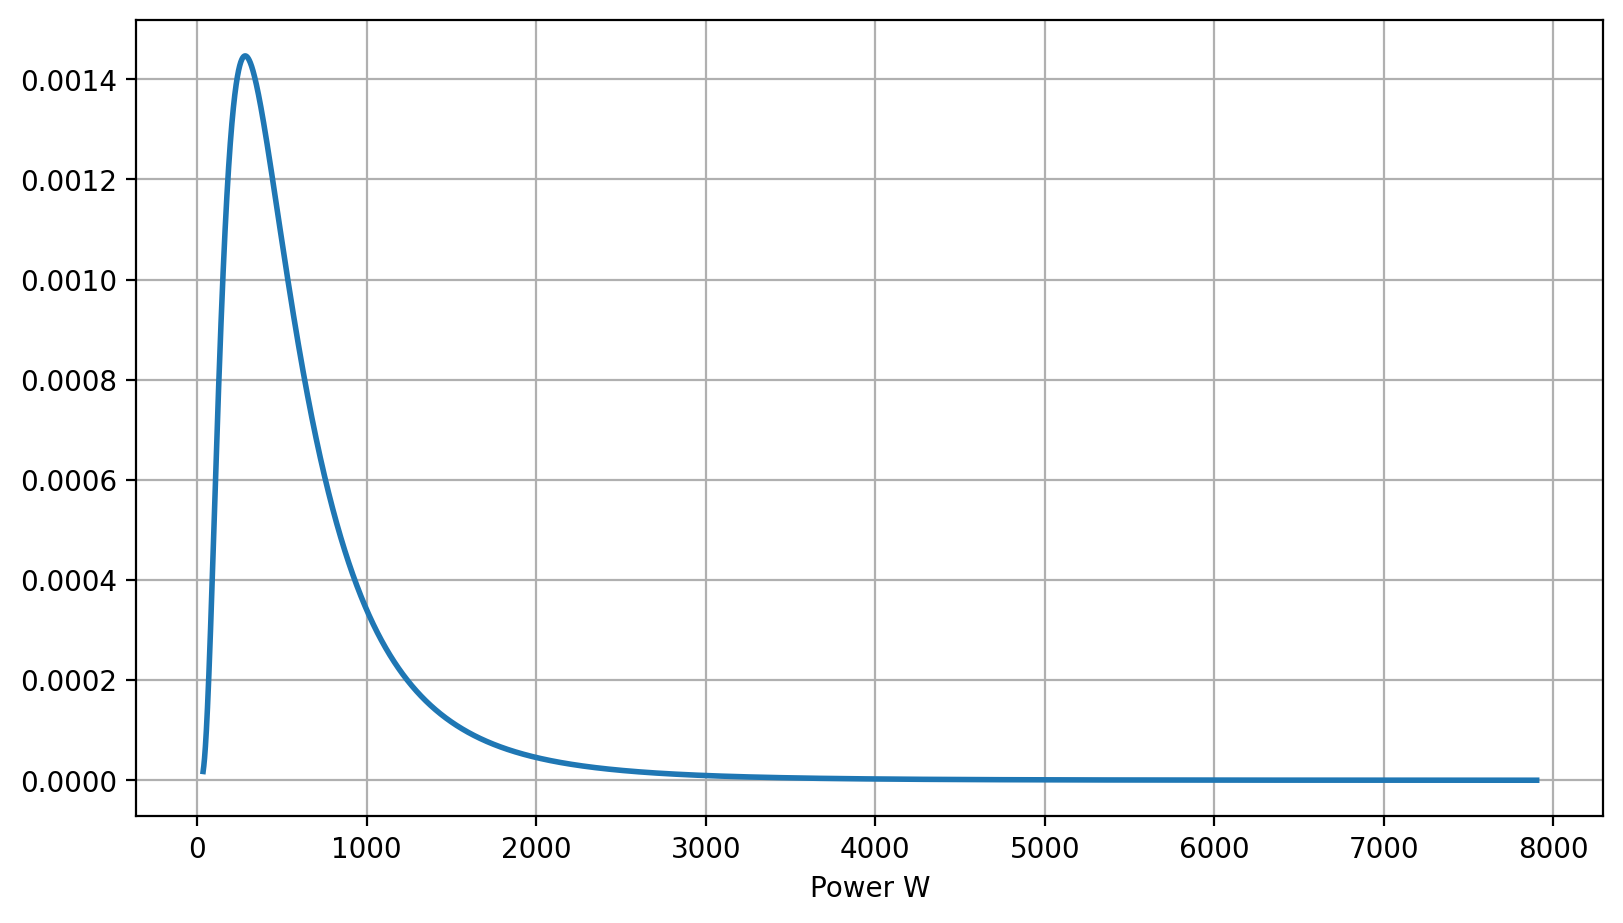

In [26]:
mean = 7.904 + np.log(0.18)
std = np.sqrt(0.5607)

print(mean, std, np.exp(mean))

x = np.linspace(scipy.stats.lognorm.ppf(0.0001, s=std, loc=mean, scale=np.exp(mean)),
                scipy.stats.lognorm.ppf(0.9999, s=std, loc=mean, scale=np.exp(mean)), int(1e5))

P_dist_eindhoven = scipy.stats.lognorm(s=std, loc=mean, scale=np.exp(mean))


fig, ax = plt.subplots(figsize=(8, 4.5), layout='constrained', dpi=200)

ax.plot(x, P_dist_eindhoven.pdf(x), lw=2)

ax.set_xlabel('Power W')
ax.grid()

plt.savefig(plot_folder/'power_distribution.pdf')
plt.show()

In [25]:
np.exp(0.5)

np.float64(1.6487212707001282)

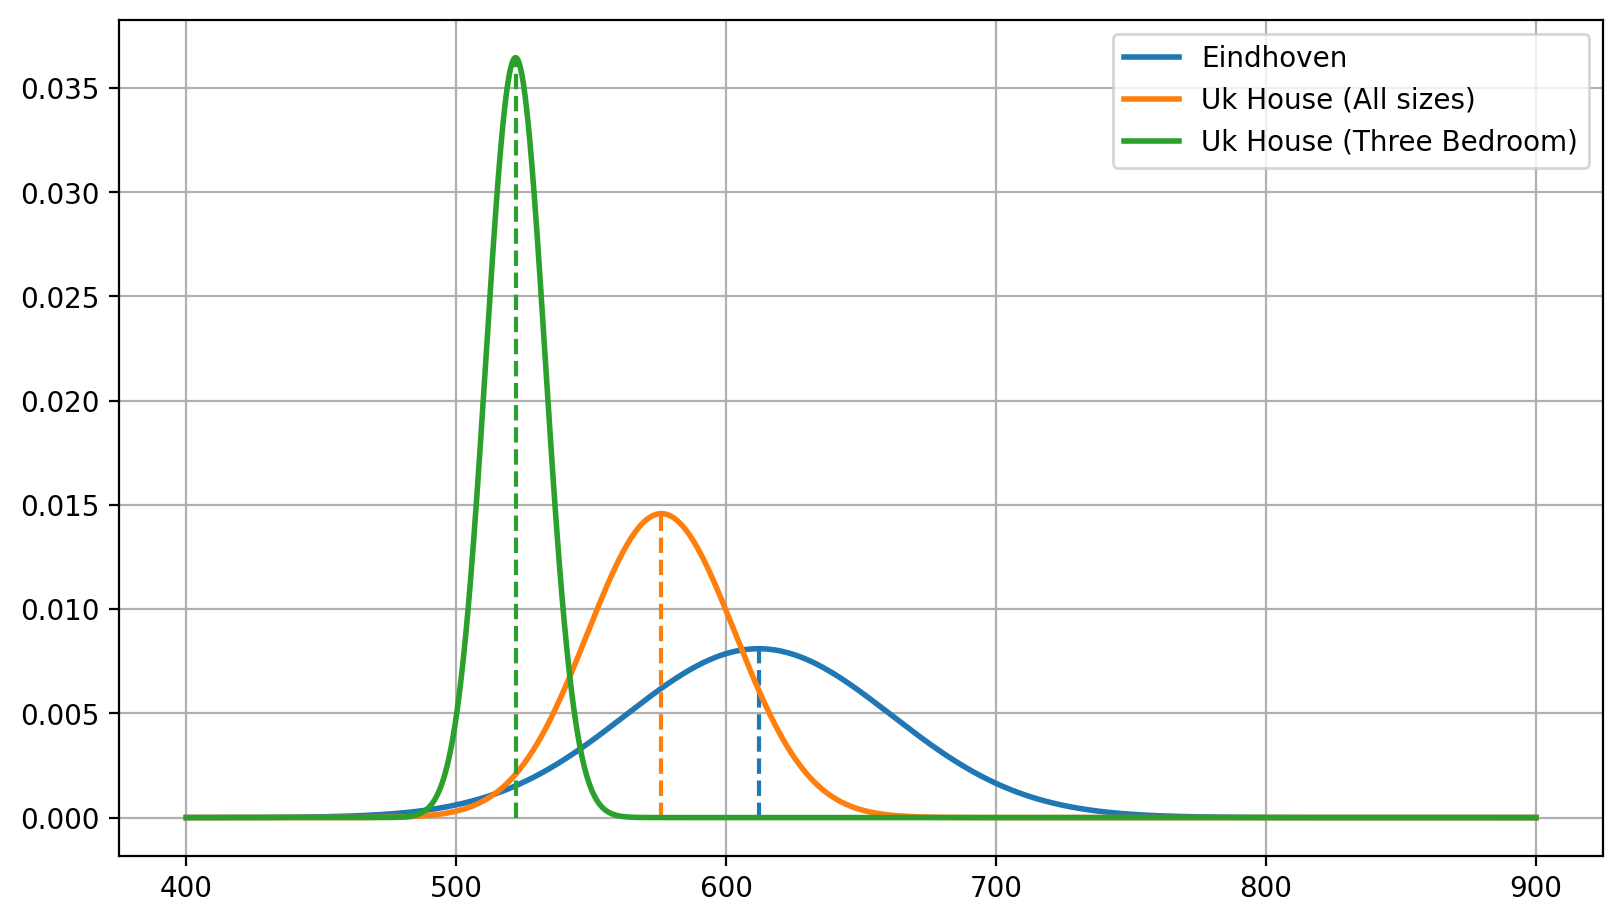

In [20]:
b_list = np.array([4.3, 3.7, 3.1])  # Values in MW
b_list *= 1e6 * 0.18/1000 # Values in W

a_list = np.array([2.5, 2.7, 2.7])  # Values in MW
a_list *= 1e6 * 0.18/1000 # Values in W

seed = 142536

labels = ['Eindhoven', 'Uk House (All sizes)', 'Uk House (Three Bedroom)', 'Eindhoven New']
colors = ['C0', 'C1', 'C2', 'C3']

distribution_list = []


for a, b, in zip(a_list, b_list):
    mean = (a + b)/2
    std = (b - a)/(2 * 3.29)

    P_dist = scipy.stats.norm(loc=mean, scale=std)
    distribution_list.append(P_dist)

#distribution_list.append(P_dist_eindhoven)

x = np.linspace(400, 900, int(1e5))
fig, ax = plt.subplots(figsize=(8, 4.5), layout='constrained', dpi=200)

for distribution, label, color in zip(distribution_list, labels, colors):

    ax.plot(x, distribution.pdf(x), lw=2, label=label)
    ax.vlines(distribution.mean(), distribution.pdf(x).min(), distribution.pdf(x).max(), color=color, ls='--')

ax.grid()
ax.legend()
plt.show()

In [21]:
v0 = 240  # Sub-station Voltage (Volts) 
sigma = 0.397/1000  # Wire resistance (ohms/metre) 
L = 20  # Cable length (metres)
num_samples = 100

v1_array = np.zeros((len(distribution_list), num_samples))

# House voltage (Volts)
def forward(v0, sigma, L, num_samples, distribution : scipy.stats._distn_infrastructure.rv_continuous_frozen):
      P = distribution.rvs(size=num_samples, random_state=seed)  # Power (Watts)
      v1 = (v0 + np.sqrt(v0**2 - 4 * sigma * L * P))/2

      return v1

for i, distribution in enumerate(distribution_list):
      v1_array[i] = forward(v0, sigma, L, num_samples=num_samples, distribution=distribution)


## Length distribution (Backward model)

In [24]:
def backward(v0, v1, sigma, num_samples, distribution : scipy.stats._distn_infrastructure.rv_continuous_frozen):
      P = distribution.rvs(size=num_samples, random_state=seed)  # Power (Watts)
      L_dist = v1 * (v0 - v1)/(sigma * P)  # Length distribution

      return L_dist

estimated_L_list = np.zeros_like(v1_array)

for i in range(100):
      v1_list = v1_array[:,i]
      fig, ax = plt.subplots(figsize=(8, 4.5), layout='constrained', dpi=200)
      
      for j, (v1, distribution, label) in enumerate(zip(v1_list, distribution_list, labels)):

            L_dist = backward(v0, v1, sigma, num_samples=int(1e5), distribution=distribution)

            bin_width = 0.5
            bins = np.arange(L_dist.min(), L_dist.max(), bin_width)

            counts, _, _ = ax.hist(L_dist, bins=bins, label=label, alpha=0.75)

            pos = np.argmax(counts)
            length = bins[pos] + bin_width/2

            estimated_L_list[j,i] = length

      ax.set_xlabel('Length (m)')
      ax.set_ylabel('Frequency')

      ax.grid()
      ax.legend()

      #bins_inset = np.arange(L-10, L+10+bin_width, 0.5)
      #ax_inset = ax.inset_axes((0.6, 0.6, 0.35, 0.35))
      #ax_inset.hist(L_dist, bins=bins_inset)
      #zoom_region = ax.indicate_inset(inset_ax=ax_inset, edgecolor='black', lw=1, ls='--', alpha=1)
      
      #for connector in zoom_region.connectors[:2]:
      #      connector.set_visible(True)

      ax.axvline(L, color='black', ls='--')
      #ax_inset.axvline(L, color='black', ls='-.')
      plt.savefig(plot_folder/f'length_distribution_{i+1}.pdf')
      plt.close()

## Error Calculations

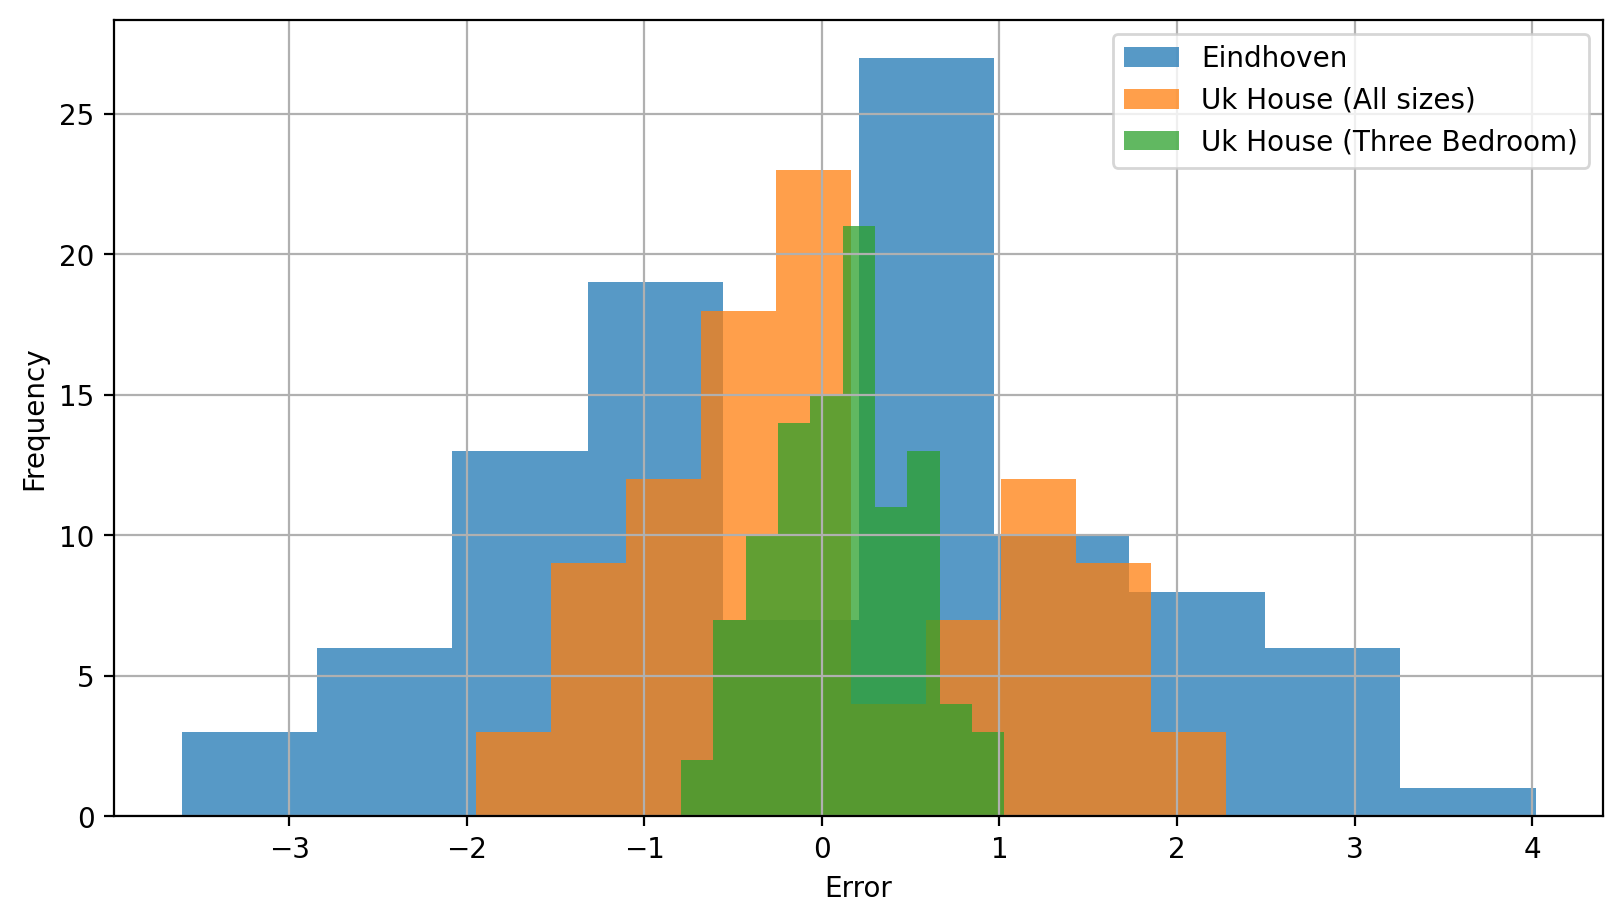

In [23]:
errors = estimated_L_list - L

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=200, layout='constrained')

for row, label in zip(errors, labels):

    ax.hist(row, bins=10, label=label, alpha=0.75)

ax.set_xlabel('Error')
ax.set_ylabel('Frequency')
ax.grid()
ax.legend()

plt.savefig(plot_folder/'error_plot.pdf')
plt.show()